In [74]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import kagglehub
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import(
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [75]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [76]:
data_path = kagglehub.dataset_download('jamaltariqcheema/pima-indians-diabetes-dataset', path='diabetes.csv')

df = pd.read_csv(data_path)

print(df.shape)
df

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76.0,48,180.0,32.9,0.171,63,0
764,2,122,70.0,27,102.5,36.8,0.340,27,0
765,5,121,72.0,23,112.0,26.2,0.245,30,0
766,1,126,60.0,32,169.5,30.1,0.349,47,1


In [77]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [78]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

,count,ratio
Outcome,,
0,500,0.651042
1,268,0.348958


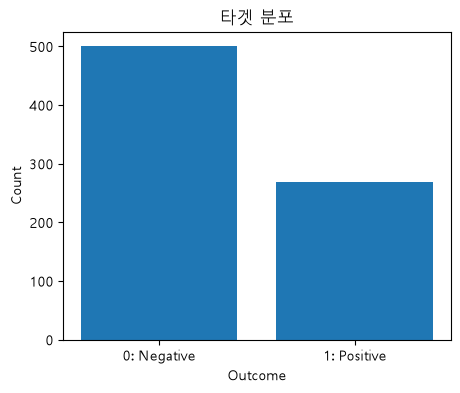

In [79]:
target_counts = df['Outcome'].value_counts().sort_index()
target_ratio = df['Outcome'].value_counts(normalize=True).sort_index()

display(pd.DataFrame({
    'count': target_counts,
    'ratio': target_ratio
}))

plt.figure(figsize=(5, 4))
plt.bar(['0: Negative', '1: Positive'], target_counts.values)
plt.title('타겟 분포')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

In [80]:
X = df.drop(columns='Outcome')
y = df['Outcome']

print(X.shape, y.shape)

(768, 8) (768,)


In [81]:
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid,
    test_size=0.2,
    stratify=y_train_valid,
    random_state=SEED
)

print(f'X_train: {X_train.shape}, X_valid: {X_valid.shape}')
print(f'y_train: {y_train.shape}, y_valid: {y_valid.shape}')

X_train: (491, 8), X_valid: (123, 8)
y_train: (491,), y_valid: (123,)


In [82]:
preprocess_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_train_scaled = preprocess_pipeline.fit_transform(X_train)
X_valid_scaled = preprocess_pipeline.transform(X_valid)
X_test_scaled = preprocess_pipeline.transform(X_test)

print(X_train_scaled.shape, X_valid_scaled.shape, X_test_scaled.shape)

(491, 8) (123, 8) (154, 8)


In [83]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_valid_tensor = torch.tensor(X_valid_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).unsqueeze(-1)
y_valid_tensor = torch.tensor(y_valid.to_numpy(), dtype=torch.float32).unsqueeze(-1)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).unsqueeze(-1)

print(f'X_train: {X_train_tensor.shape}, X_valid: {X_valid_tensor.shape}, X_test: {X_test_tensor.shape}')
print(f'y_train: {y_train_tensor.shape}, y_valid: {y_valid_tensor.shape}, y_test: {y_test_tensor.shape}')

X_train: torch.Size([491, 8]), X_valid: torch.Size([123, 8]), X_test: torch.Size([154, 8])
y_train: torch.Size([491, 1]), y_valid: torch.Size([123, 1]), y_test: torch.Size([154, 1])


In [84]:
BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(len(train_loader), len(valid_loader), len(test_loader))

16 4 5


In [85]:
class DiabetsMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=(64, 32, 16), dropout=0.2, activation='silu'):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))

            if activation == 'relu':
                layers.append(nn.ReLU())
            elif activation == 'gelu':
                layers.append(nn.GELU())
            elif activation == 'silu':
                layers.append(nn.SiLU())
            else:
                raise ValueError('활성화함수는 relu, gelu, silu 중 하나로 선택')

            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [86]:
input_dim = X_train_tensor.size(-1)

model = DiabetsMLP(
    input_dim=input_dim,
).to(device)

model

DiabetsMLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): SiLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): SiLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [87]:
num_positive = y_train_tensor.sum()
num_negative = len(y_train_tensor) - num_positive
pos_weight = (num_negative / num_positive).to(device)

print(f'pos_weight: {pos_weight}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

pos_weight: 1.871345043182373


In [88]:
class EarlyStopping:
    def __init__(self, patience=20, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = np.inf
        self.counter = 0
        self.best_state = None
        self.should_stop = False

    def step(self, valid_loss, model):
        if valid_loss < self.best_loss - self.min_delta:
            self.best_loss = valid_loss
            self.counter = 0
            self.best_state = {
                key: value.detach().cpu().clone() for key, value in model.state_dict().items()
            }
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

In [89]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(X_batch)

    return total_loss / len(data_loader.dataset)

def evaluate_loss(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * len(X_batch)
            
    return total_loss / len(data_loader.dataset)

In [90]:
EPOCHS = 150

early_stopping = EarlyStopping(patience=20, min_delta=0.0001)

history = []

for epoch in tqdm(range(EPOCHS), desc='Training'):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    valid_loss = evaluate_loss(model, valid_loader, criterion, device)

    scheduler.step(valid_loss)

    current_lr = optimizer.param_groups[0]['lr']

    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'valid_loss': valid_loss,
        'lr': current_lr
    })

    early_stopping.step(valid_loss, model)
    if early_stopping.should_stop:
        print(f'{epoch + 1} Epoch Early Stopped')
        break

if early_stopping.best_state is not None:
    model.load_state_dict(early_stopping.best_state)

history_df = pd.DataFrame(history)
history_df

Training:  53%|█████▎    | 80/150 [00:04<00:03, 20.00it/s]

81 Epoch Early Stopped


,epoch,train_loss,valid_loss,lr
0,1,0.843492,0.835021,0.001000
1,2,0.750661,0.700958,0.001000
2,3,0.686304,0.624646,0.001000
3,4,0.677374,0.592313,0.001000
4,5,0.658997,0.563000,0.001000
...,...,...,...,...
76,77,0.411932,0.377969,0.000031
77,78,0.459212,0.372900,0.000031
78,79,0.440543,0.368762,0.000016
79,80,0.438642,0.366695,0.000016


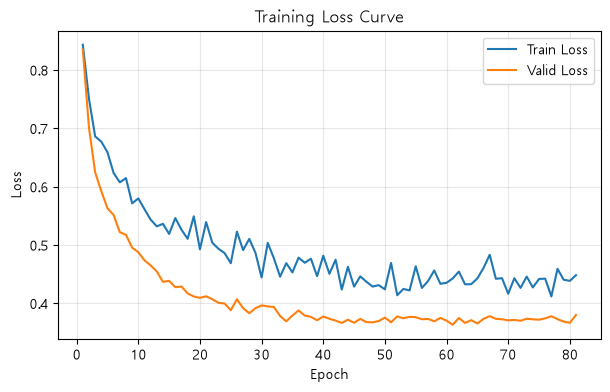

In [94]:
plt.figure(figsize=(7, 4))
plt.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss')
plt.plot(history_df['epoch'], history_df['valid_loss'], label='Valid Loss')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

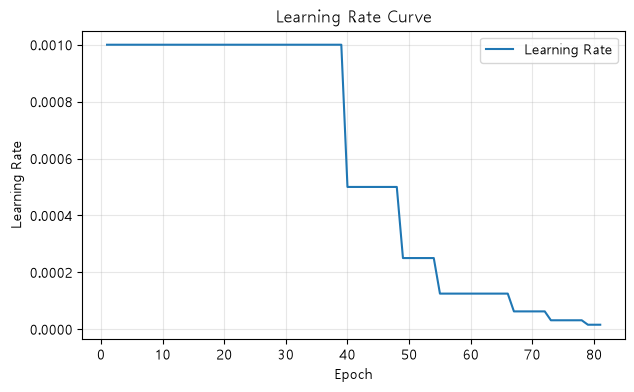

In [97]:
plt.figure(figsize=(7, 4))
plt.plot(history_df['epoch'], history_df['lr'], label='Learning Rate')
plt.title('Learning Rate Curve')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [99]:
def predict_proba(model, data_loader, device):
    model.eval()
    proba_list = []
    target_list = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)

            logits = model(X_batch)
            proba = torch.sigmoid(logits)

            proba_list.append(proba.cpu().numpy())
            target_list.append(y_batch.numpy())

    y_proba = np.vstack(proba_list).ravel()
    y_true = np.vstack(target_list).ravel()

    return y_true, y_proba

- validation 데이터로 threshold 확인하고 변경해 지표 확인
    - 기본 임계값은 0.5
    - 모델 목적에 따라 임계값 조정해서 사용
    - 양성 클래스 잡는게 목적이면 recall 우선

In [ ]:
y_valid_true, y_valid_proba = predict_proba(model, valid_loader, device)

thresholds = np.arange(0.1, 0.91, 0.05)

threshold_result = []

for threhold in thresholds:
    y_valid_pred = (y_valid_proba >= threhold).astype(int)

    threshold_result.append({
        'threshold': threhold,
        'accuracy': accuracy_score(y_valid_true, y_valid_pred),
        'precision': precision_score(y_valid_true, y_valid_pred, zero_division=0),
        'recall': recall_score(y_valid_true, y_valid_pred, zero_division=0),
        'f1': f1_score(y_valid_true, y_valid_pred, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_result)
threshold_df.sort_values('f1', ascending=False).head()

,threshold,accuracy,precision,recall,f1
10,0.60,0.894309,0.812500,0.906977,0.857143
13,0.75,0.894309,0.875000,0.813953,0.843373
12,0.70,0.894309,0.875000,0.813953,0.843373
9,0.55,0.869919,0.754717,0.930233,0.833333
11,0.65,0.878049,0.818182,0.837209,0.827586


In [101]:
best_threshold = threshold_df.sort_values('f1', ascending=False).iloc[0]['threshold']
best_threshold

np.float64(0.6000000000000002)

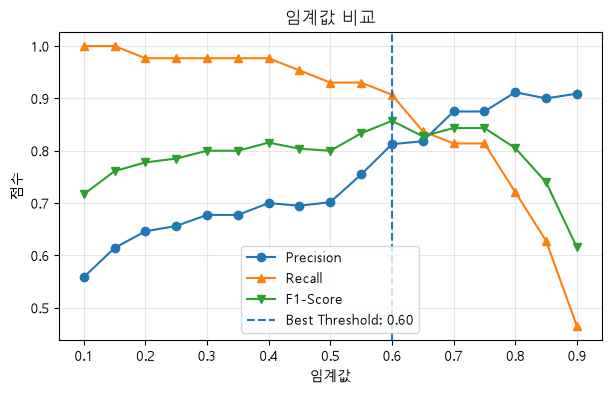

In [102]:
plt.figure(figsize=(7, 4))
plt.plot(threshold_df['threshold'], threshold_df['precision'], marker='o', label='Precision')
plt.plot(threshold_df['threshold'], threshold_df['recall'], marker='^', label='Recall')
plt.plot(threshold_df['threshold'], threshold_df['f1'], marker='v', label='F1-Score')
plt.axvline(best_threshold, linestyle='--', label=f'Best Threshold: {best_threshold:.2f}')
plt.title('임계값 비교')
plt.xlabel('임계값')
plt.ylabel('점수')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [105]:
y_test_true, y_test_proba = predict_proba(model, test_loader, device)
y_test_pred = (y_test_proba >= best_threshold).astype(int)

test_metrics = {
    'accuracy': accuracy_score(y_test_true, y_test_pred),
    'precision': precision_score(y_test_true, y_test_pred, zero_division=0),
    'recall': recall_score(y_test_true, y_test_pred, zero_division=0),
    'f1': f1_score(y_test_true, y_test_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test_true, y_test_proba),
    'pr_auc': average_precision_score(y_test_true, y_test_proba)
}

pd.DataFrame([test_metrics])

,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.87013,0.814815,0.814815,0.814815,0.914444,0.824229


In [109]:
print(classification_report(y_test_true, y_test_pred, target_names=['Negative', 'Positive'], zero_division=0))

              precision    recall  f1-score   support

    Negative       0.90      0.90      0.90       100
    Positive       0.81      0.81      0.81        54

    accuracy                           0.87       154
   macro avg       0.86      0.86      0.86       154
weighted avg       0.87      0.87      0.87       154



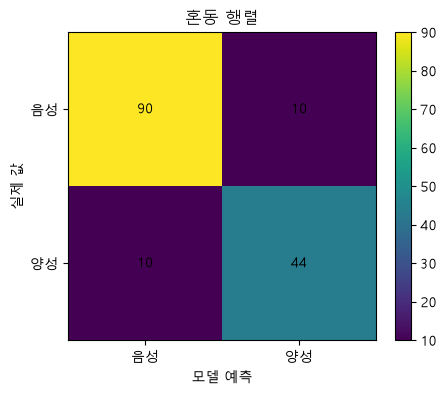

In [113]:
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title('혼동 행렬')
plt.xlabel('모델 예측')
plt.ylabel('실제 값')
plt.xticks([0, 1], ['음성', '양성'])
plt.yticks([0, 1], ['음성', '양성'])
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

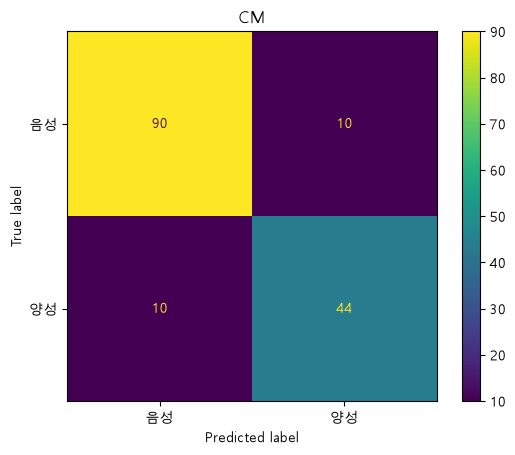

In [114]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test_true, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['음성', '양성'],
)

disp.plot()
plt.title('CM')
plt.show()

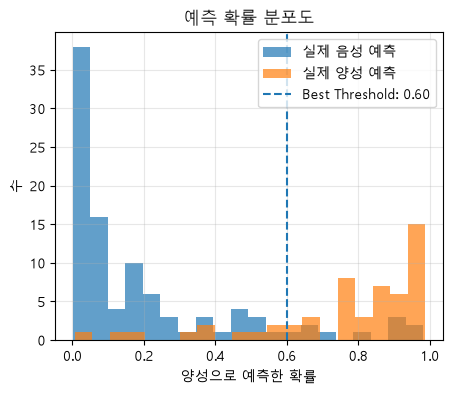

In [115]:
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5, 4))
plt.hist(y_test_proba[y_test_true == 0], bins=20, alpha=0.7, label='실제 음성 예측')
plt.hist(y_test_proba[y_test_true == 1], bins=20, alpha=0.7, label='실제 양성 예측')
plt.axvline(best_threshold, linestyle='--', label=f'Best Threshold: {best_threshold:.2f}')
plt.title('예측 확률 분포도')
plt.xlabel('양성으로 예측한 확률')
plt.ylabel('수')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [116]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [144]:
sample = pd.DataFrame([{
    'Pregnancies': 2,
    'Glucose': 130,
    'BloodPressure': 140,
    'SkinThickness': 25,
    'Insulin': 90,
    'BMI': 38.5,
    'DiabetesPedigreeFunction': 0.95,
    'Age': 35
}])

sample_scale = preprocess_pipeline.transform(sample)
sample_tensor = torch.FloatTensor(sample_scale).to(device)

model.eval()
with torch.no_grad():
    logit = model(sample_tensor)
    proba = torch.sigmoid(logit).item()
    pred = int(proba >= best_threshold)

print(f'양성 클래스일 확률: {proba:.4f}, 예측 클래스: {pred}')

양성 클래스일 확률: 0.1811, 예측 클래스: 0
